In [1]:
import json
import pandas as pd
import os
from benchmarks import load_cbenchio_reports,get_report_filenames
from matplotlib import pyplot as plt
import seaborn as sns
import re
import numpy as np
sns.set_style("whitegrid")

# Results from syntethic benchmarks using cbenchio

## MPI-IO 1D

In [4]:
base_path="/work/z19/z19/lparisi/nfs-testing/run-reframe/"
filenames= ["mpi1DLustreN1-16T1-288Snum_nodesF4-32M.json","mpi1DVastN1-16T1-288Snum_nodesF4-32M.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
data["field_size_per_process_per_dimension"]/=2**20
data

,name,nodes,tasks_per_node,base_path,api,stripes,field_size_per_process_per_dimension,bandwidth,filesystem
0,cbenchio_mpi_1D_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,4.0,0.278684,lustre
1,cbenchio_mpi_1D_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,16.0,0.935032,lustre
2,cbenchio_mpi_1D_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,32.0,1.076893,lustre
3,cbenchio_mpi_1D_write,1,2,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,4.0,0.722016,lustre
4,cbenchio_mpi_1D_write,1,2,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,16.0,1.285103,lustre
...,...,...,...,...,...,...,...,...,...
2392,cbenchio_mpi_1D_read,16,8,/vast/data/lparisi,mpi,1,16.0,23.072627,vast
2393,cbenchio_mpi_1D_read,16,8,/vast/data/lparisi,mpi,1,32.0,34.589511,vast
2394,cbenchio_mpi_1D_read,16,24,/vast/data/lparisi,mpi,1,4.0,18.186968,vast
2395,cbenchio_mpi_1D_read,16,24,/vast/data/lparisi,mpi,1,16.0,39.718700,vast


### Single node performance

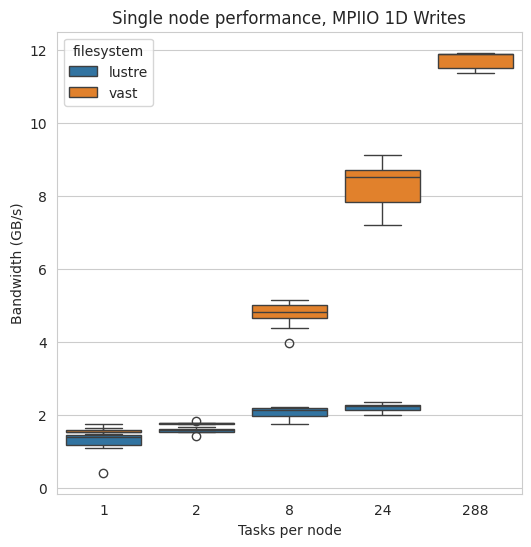

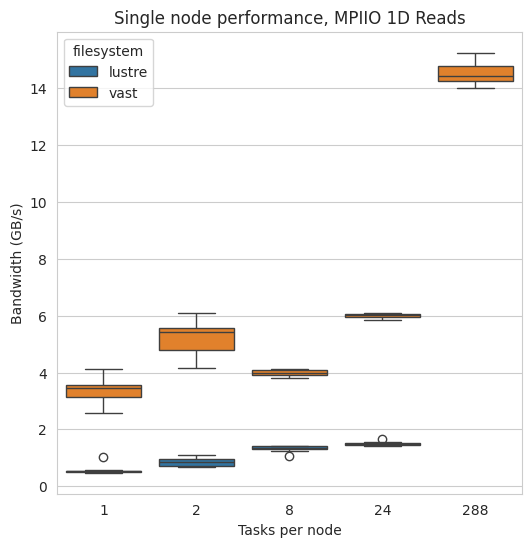

In [5]:
for operation in ["write","read"]:
    fix,ax = plt.subplots(figsize=(6, 6))
    plot_data = data.query(f"nodes==1 & field_size_per_process_per_dimension=={32} & stripes == 1 & name=='cbenchio_mpi_1D_{operation}'")
    sns.boxplot(data=plot_data, x="tasks_per_node", y="bandwidth", hue="filesystem",dodge=False)
    plt.savefig(f"single_node_performance_mpi_1D_{operation}.png", dpi=300, bbox_inches="tight")
    ax.set_title(f"Single node performance, MPIIO 1D {operation.capitalize()}s")
    ax.set_ylabel("Bandwidth (GB/s)")
    ax.set_xlabel("Tasks per node")



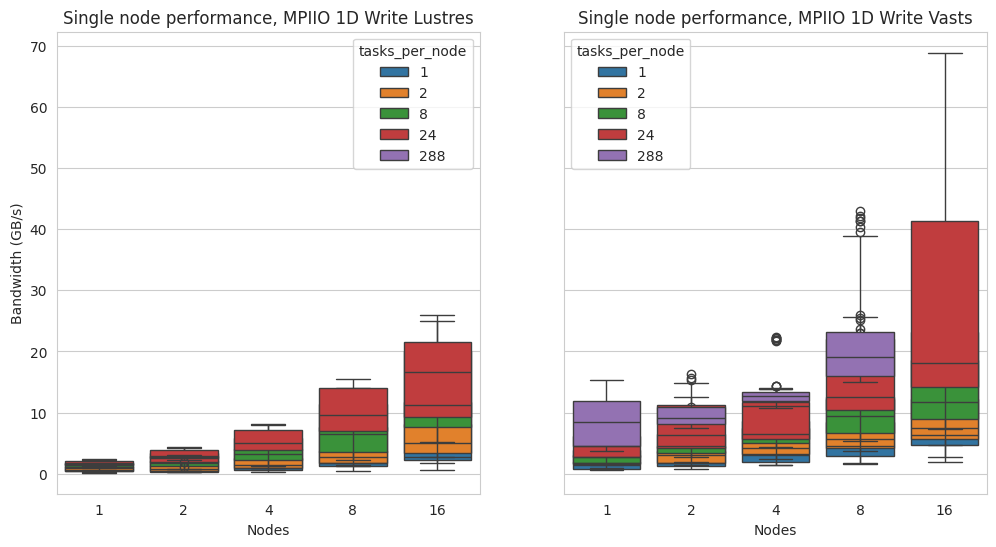

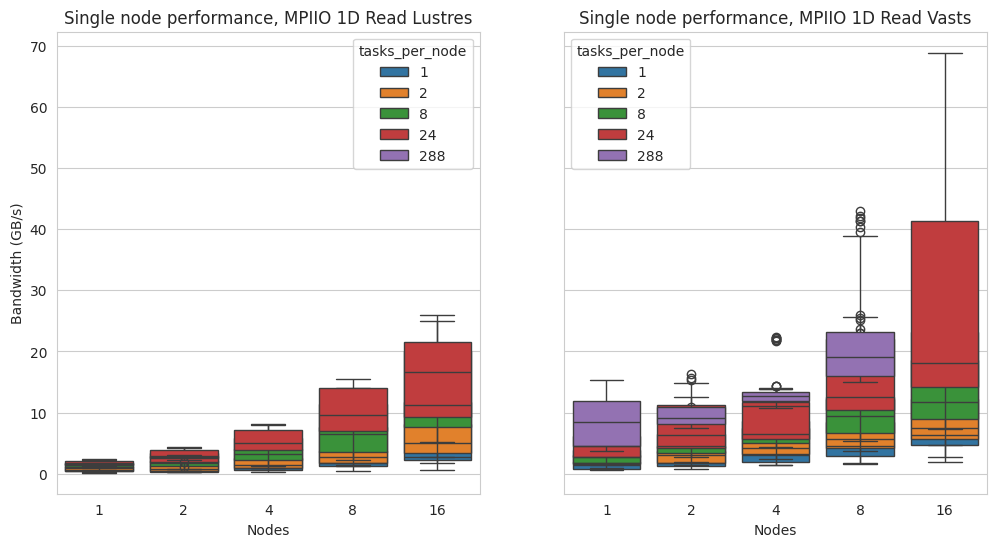

In [6]:
for operation in ["write","read"]:
    fix,ax = plt.subplots(1, 2, figsize=(12, 6),sharey=True)
    for i,filesystem in enumerate(["lustre","vast"]):
        plot_data = data.query(f" field_size_per_process_per_dimension==32 & name=='cbenchio_mpi_1D_{operation}'")
        plot_data=data.query(f"filesystem=='{filesystem}' ")
        plot_data["tasks_per_node"]=plot_data["tasks_per_node"].astype(str)
        sns.boxplot(data=plot_data, x="nodes", y="bandwidth", hue="tasks_per_node",dodge=False,ax=ax[i])
        ax[i].set_title(f"Single node performance, MPIIO 1D {operation.capitalize()} {filesystem.capitalize()}s")
        ax[i].set_ylabel("Bandwidth (GB/s)")
        ax[i].set_xlabel("Nodes")
    plt.savefig(f"single_node_performance_mpi_1D_{operation}.png", dpi=300, bbox_inches="tight")

## MPI 3D array

In [7]:
base_path="/work/z19/z19/lparisi/nfs-testing/run-reframe/"
filenames= ["mpi3DVastN1-16T1-288F4-32M.json","mpi3DLustreN1-16T1-288F4-32M.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
set(data["filesystem"])
data

,name,nodes,tasks_per_node,base_path,api,stripes,field_size_per_process_per_dimension,bandwidth,filesystem
0,cbenchio_mpi_3D_write,1,1,/vast/lparisi/data,mpi,1,128,0.013894,vast
1,cbenchio_mpi_3D_write,1,1,/vast/lparisi/data,mpi,1,512,0.444223,vast
2,cbenchio_mpi_3D_write,1,1,/vast/lparisi/data,mpi,1,2048,2.936202,vast
3,cbenchio_mpi_3D_write,1,2,/vast/lparisi/data,mpi,1,128,0.017531,vast
4,cbenchio_mpi_3D_write,1,2,/vast/lparisi/data,mpi,1,512,0.543804,vast
...,...,...,...,...,...,...,...,...,...
1914,cbenchio_mpi_3D_read,12,24,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,-1,128,0.304232,lustre
1915,cbenchio_mpi_3D_read,12,24,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,-1,512,10.671270,lustre
1916,cbenchio_mpi_3D_read,12,24,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,-1,2048,19.433120,lustre
1917,cbenchio_mpi_3D_read,12,288,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,-1,128,1.791549,lustre


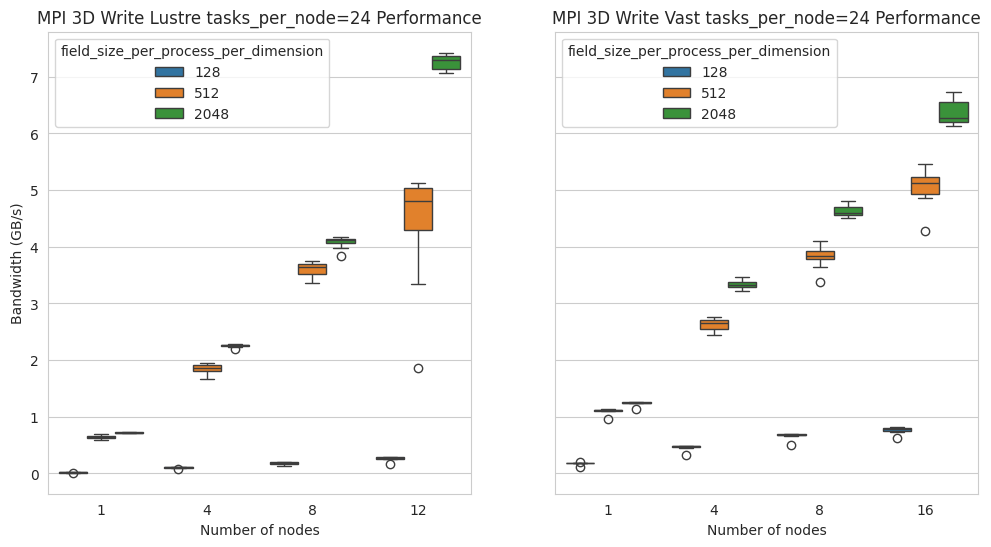

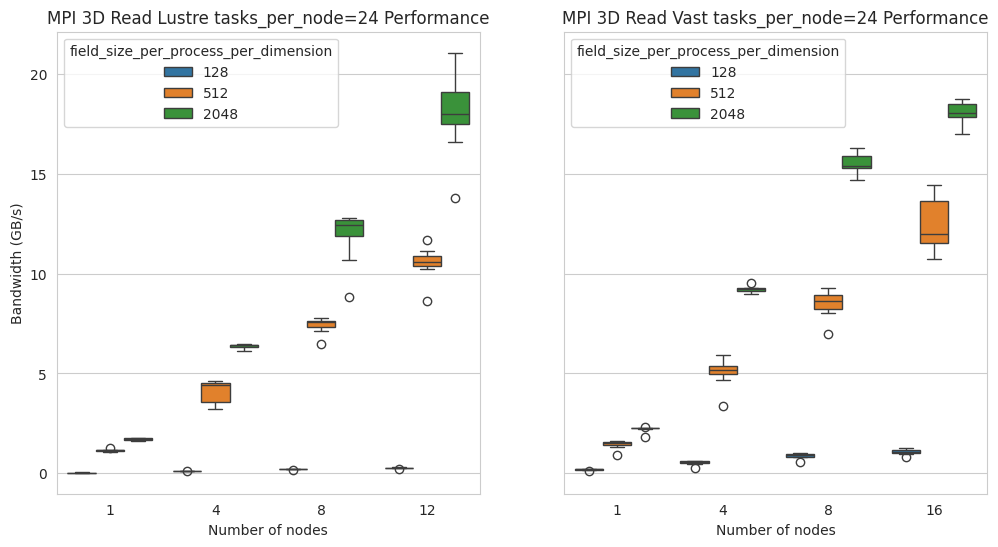

In [8]:
for i,operation in enumerate(["write","read"]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    tasks_per_node = 24
    for i,filesystem in enumerate(["lustre","vast"]):
        plot_data=data.query(f"name=='cbenchio_mpi_3D_{operation}' & filesystem=='{filesystem}' & tasks_per_node=={tasks_per_node}")
        plot_data["field_size_per_process_per_dimension"]=plot_data["field_size_per_process_per_dimension"].astype(str)
        if filesystem == "lustre":
            plot_data = plot_data.query("stripes==-1")
        #plot_data["chunk_size"]=(np.array(plot_data["chunk_size"]).astype(float).astype(int)).astype(str) + " KiB"
        sns.boxplot(ax=axes[i], data=plot_data, x="nodes", y="bandwidth", hue="field_size_per_process_per_dimension",dodge=True)
        axes[i].set_ylabel("Bandwidth (GB/s)")
        axes[i].set_xlabel("Number of nodes")
        axes[i].set_title(f"MPI 3D {operation.capitalize()} {filesystem.capitalize()} tasks_per_node={tasks_per_node} Performance")


    plt.savefig(f"mpi_3D_{operation}_tasks_perNode{tasks_per_node}.png", dpi=300, bbox_inches="tight")


## Sequential POSIX 

In [10]:
base_path="/work/z19/z19/lparisi/nfs-testing/run-reframe/"
filenames= ["posixVASTN1T1-288C4K-32MF0.5G.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
data["chunk_size"]= data["chunk_size"].astype(int)/2**10
data

,name,nodes,tasks_per_node,base_path,api,chunk_size,field_size_per_process_per_dimension,bandwidth,stripes,filesystem
0,cbenchio_posix_sequential_write,1,1,/vast/lparisi/data,posix,4.0,536870912,1.851014,1,vast
1,cbenchio_posix_sequential_write,1,1,/vast/lparisi/data,posix,1024.0,536870912,4.956691,1,vast
2,cbenchio_posix_sequential_write,1,1,/vast/lparisi/data,posix,4096.0,536870912,3.532827,1,vast
3,cbenchio_posix_sequential_write,1,1,/vast/lparisi/data,posix,32768.0,536870912,5.305430,1,vast
4,cbenchio_posix_sequential_write,1,2,/vast/lparisi/data,posix,4.0,536870912,2.327558,1,vast
...,...,...,...,...,...,...,...,...,...,...
507,cbenchio_posix_sequential_read,1,96,/vast/lparisi/data,posix,32768.0,536870912,23.068088,1,vast
508,cbenchio_posix_sequential_read,1,288,/vast/lparisi/data,posix,4.0,536870912,23.226819,1,vast
509,cbenchio_posix_sequential_read,1,288,/vast/lparisi/data,posix,1024.0,536870912,22.933679,1,vast
510,cbenchio_posix_sequential_read,1,288,/vast/lparisi/data,posix,4096.0,536870912,23.897023,1,vast


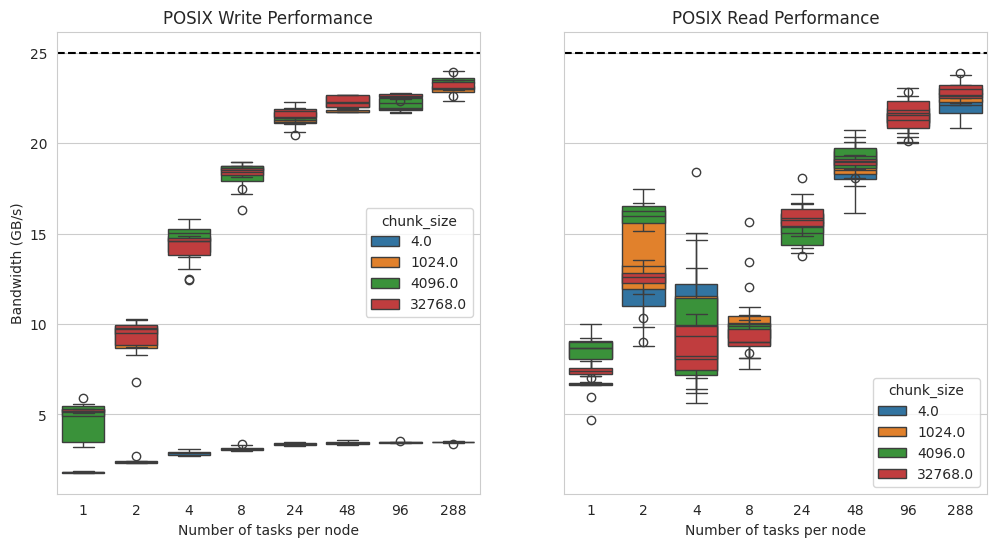

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for i,operation in enumerate(["write","read"]):
    plot_data=data.query(f"name=='cbenchio_posix_sequential_{operation}'")
    plot_data["chunk_size"]=plot_data["chunk_size"].astype(str)
    sns.boxplot(ax=axes[i], data=plot_data, x="tasks_per_node", y="bandwidth", hue="chunk_size",dodge=False)
    axes[i].set_ylabel("Bandwidth (GB/s)")
    axes[i].set_xlabel("Number of tasks per node")
    axes[i].set_title(f"POSIX {operation.capitalize()} Performance")

    # Horizontal line at 25GB/s
    axes[i].axhline(y=25, color='black', linestyle='--')

plt.savefig("single_node_performance_VAST_posix.png", dpi=300, bbox_inches="tight")


## Random POSIX

In [13]:
base_path="/work/z19/z19/lparisi/nfs-testing/run-reframe/"
filenames= ["posixVASTN1-16T1-288C4K-32MRandom.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
data["chunk_size"]= data["chunk_size"].astype(str)
data

,name,nodes,tasks_per_node,base_path,api,chunk_size,field_size_per_process_per_dimension,bandwidth,stripes,filesystem
0,cbenchio_posix_random_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,posix,128,65536,0.008738,1,lustre
1,cbenchio_posix_random_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,posix,256,65536,0.006962,1,lustre
2,cbenchio_posix_random_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,posix,1024,65536,0.005985,1,lustre
3,cbenchio_posix_random_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,posix,4096,65536,0.007921,1,lustre
4,cbenchio_posix_random_write,1,4,/work/z19/z19/lparisi/nfs-testing/run/data,posix,128,65536,0.014362,1,lustre
...,...,...,...,...,...,...,...,...,...,...
1595,cbenchio_posix_random_read,16,24,/work/z19/z19/lparisi/nfs-testing/run/data,posix,4096,65536,1.098953,1,lustre
1596,cbenchio_posix_random_read,16,288,/work/z19/z19/lparisi/nfs-testing/run/data,posix,128,65536,2.820438,1,lustre
1597,cbenchio_posix_random_read,16,288,/work/z19/z19/lparisi/nfs-testing/run/data,posix,256,65536,1.538545,1,lustre
1598,cbenchio_posix_random_read,16,288,/work/z19/z19/lparisi/nfs-testing/run/data,posix,1024,65536,3.363955,1,lustre


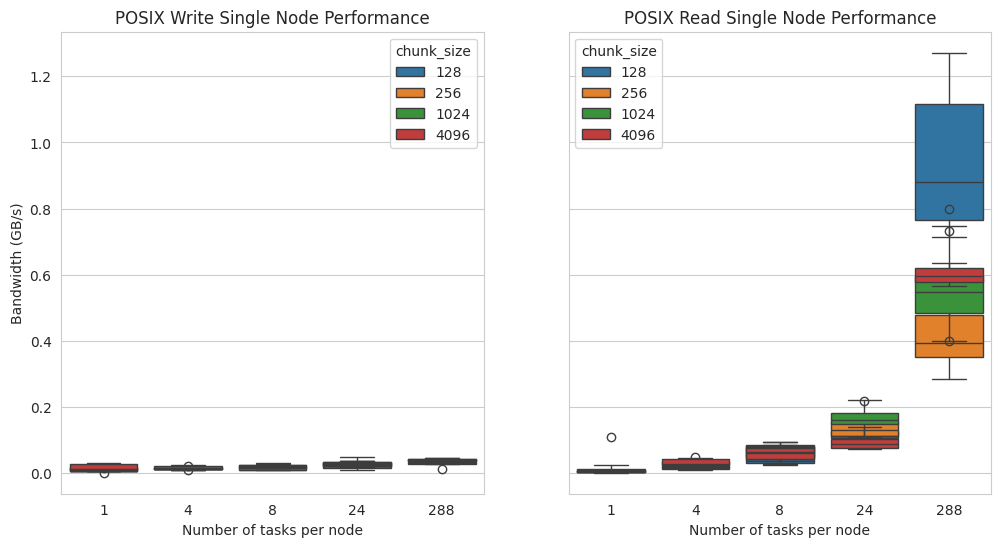

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for i,operation in enumerate(["write","read"]):
    plot_data=data.query(f"name=='cbenchio_posix_random_{operation}' ").query("nodes==1")
    #plot_data["chunk_size"]=(np.array(plot_data["chunk_size"]).astype(float).astype(int)).astype(str) + " KiB"
    sns.boxplot(ax=axes[i], data=plot_data, x="tasks_per_node", y="bandwidth", hue="chunk_size",dodge=False)
    axes[i].set_ylabel("Bandwidth (GB/s)")
    axes[i].set_xlabel("Number of tasks per node")
    axes[i].set_title(f"POSIX {operation.capitalize()} Single Node Performance")

plt.savefig("single_node_performance_VAST_posix_random.png", dpi=300, bbox_inches="tight")


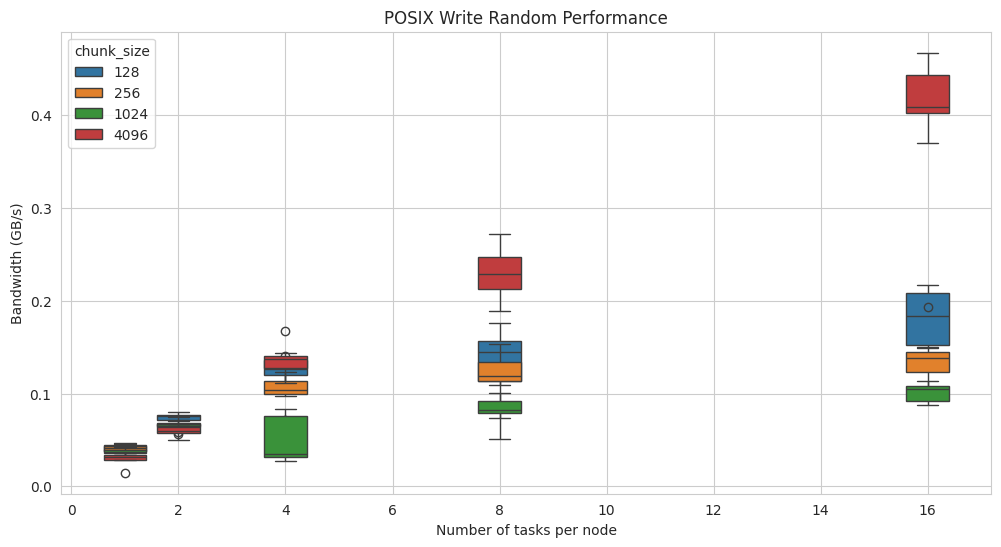

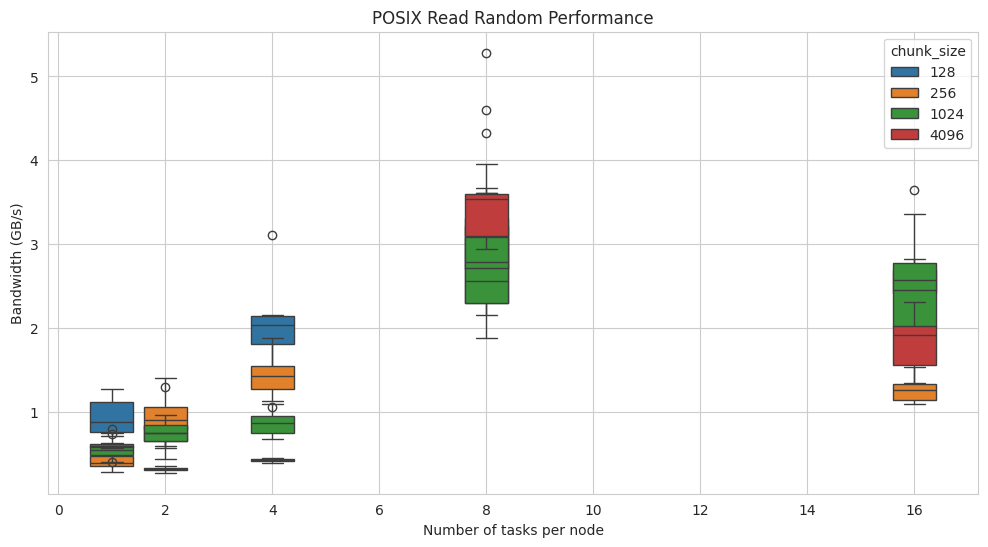

In [18]:
for i,operation in enumerate(["write","read"]):
    fig, axes = plt.subplots(1, 1, figsize=(12, 6))
    plot_data=data.query(f"name=='cbenchio_posix_random_{operation}'" ).query("tasks_per_node==288")
    #plot_data["chunk_size"]=(np.array(plot_data["chunk_size"]).astype(float).astype(int)).astype(str) + " KiB"
    sns.boxplot(ax=axes, data=plot_data, x="nodes", y="bandwidth", hue="chunk_size",dodge=False,native_scale=True)
    axes.set_ylabel("Bandwidth (GB/s)")
    axes.set_xlabel("Number of tasks per node")
    axes.set_title(f"POSIX {operation.capitalize()} Random Performance")


    plt.savefig(f"single_node_performance_VAST_posix_{operation}_random.png", dpi=300, bbox_inches="tight")